In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("../data/raw/customer_churn.xlsx")

In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.shape

(7043, 33)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [7]:
df.isnull()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [8]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique().sort_values()

Count                   1
Country                 1
State                   1
Phone Service           2
Dependents              2
Partner                 2
Senior Citizen          2
Gender                  2
Churn Value             2
Paperless Billing       2
Churn Label             2
Multiple Lines          3
Internet Service        3
Online Backup           3
Online Security         3
Tech Support            3
Contract                3
Streaming Movies        3
Streaming TV            3
Device Protection       3
Payment Method          4
Churn Reason           20
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Latitude             1652
Lat Long             1652
Zip Code             1652
CLTV                 3438
Total Charges        6531
CustomerID           7043
dtype: int64

In [11]:
df['Count']

0       1
1       1
2       1
3       1
4       1
       ..
7038    1
7039    1
7040    1
7041    1
7042    1
Name: Count, Length: 7043, dtype: int64

In [12]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [14]:
df["Churn Label"].map({'No':0,'Yes':1})

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Label, Length: 7043, dtype: int64

In [15]:
(df["Total Charges"].astype(str).str.strip() == "").sum()

np.int64(11)

In [16]:
for col in ["Count", "Country", "State"]:
    print(col, df[col].nunique())

Count 1
Country 1
State 1


In [17]:
for col in [
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(10))


 Churn Label
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

 Churn Value
Churn Value
0    5174
1    1869
Name: count, dtype: int64

 Churn Score
Churn Score
80    151
71    148
77    145
67    143
68    141
76    141
70    140
69    140
78    138
72    137
Name: count, dtype: int64

 Churn Reason
Churn Reason
NaN                                          5174
Attitude of support person                    192
Competitor offered higher download speeds     189
Competitor offered more data                  162
Don't know                                    154
Competitor made better offer                  140
Attitude of service provider                  135
Competitor had better devices                 130
Network reliability                           103
Product dissatisfaction                       102
Name: count, dtype: int64


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [19]:
df.nunique().sort_values()

Count                   1
Country                 1
State                   1
Phone Service           2
Dependents              2
Partner                 2
Senior Citizen          2
Gender                  2
Churn Value             2
Paperless Billing       2
Churn Label             2
Multiple Lines          3
Internet Service        3
Online Backup           3
Online Security         3
Tech Support            3
Contract                3
Streaming Movies        3
Streaming TV            3
Device Protection       3
Payment Method          4
Churn Reason           20
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Latitude             1652
Lat Long             1652
Zip Code             1652
CLTV                 3438
Total Charges        6531
CustomerID           7043
dtype: int64

#why these columns are dropped
| Column                             | Decision       | Reason                              |
| ---------------------------------- | -------------- | ----------------------------------- |
| CustomerID                         | Drop           | Identifier                          |
| Count                              | Drop           | Constant feature                    |
| Country                            | Drop           | Constant feature                    |
| State                              | Drop           | Constant feature                    |
| City                               | Drop initially | High-cardinality geographic feature |
| Zip Code                           | Drop initially | Geographic feature                  |
| Lat Long                           | Drop initially | Geographic feature                  |
| Latitude                           | Drop initially | Geographic feature                  |
| Longitude                          | Drop initially | Geographic feature                  |
| Churn Value                        | Drop           | Target leakage                      |
| Churn Score                        | Drop           | Target leakage                      |
| Churn Reason                       | Drop           | Target-derived information          |
| Churn Label                        | Target         | Prediction target                   |
| Remaining customer/service columns | Keep           | Candidate predictive features       |


In [20]:
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

df_model = df.drop(columns=columns_to_drop)

X = df_model.drop(columns=["Churn Label"])
y = df_model["Churn Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nRemaining columns:")
print(X.columns.tolist())

X shape: (7043, 20)
y shape: (7043,)

Remaining columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV']


In [21]:
df_model.head()


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,5340


In [22]:
df_model.shape

(7043, 21)

In [23]:
y

0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
7038     No
7039     No
7040     No
7041     No
7042     No
Name: Churn Label, Length: 7043, dtype: object

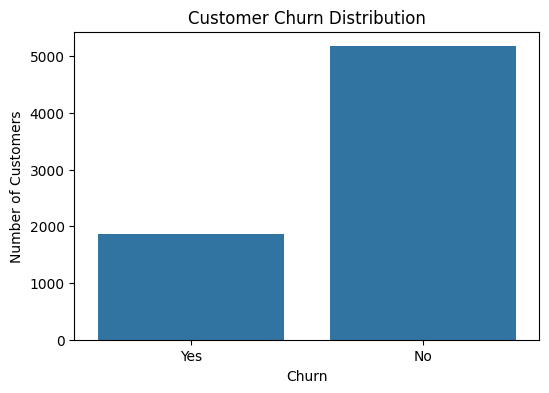

In [24]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_model,
    x="Churn Label"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [25]:
churn_percentage = (
    df_model["Churn Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


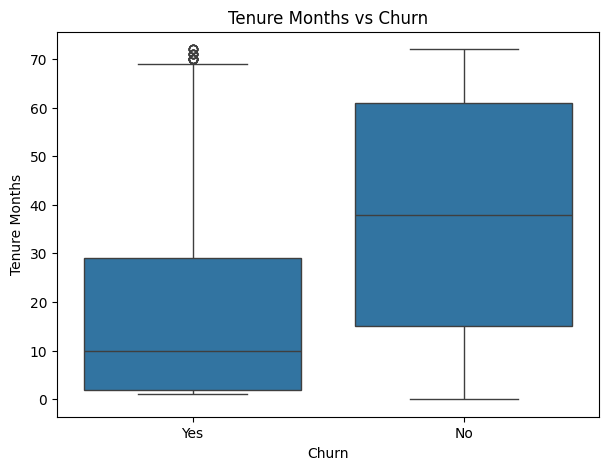

In [26]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_model,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure Months vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure Months")

plt.show()

Tenure Months vs Churn — Observation

The boxplot shows a substantial difference in tenure between churned and non-churned customers. Churned customers have a much lower median tenure of approximately 10 months, while non-churned customers have a median tenure of approximately 38 months. This indicates that lower customer tenure is strongly associated with churn in this dataset. However, there is still overlap between the two groups, indicating that tenure alone cannot determine churn. Several high-tenure churned customers appear as potential outliers and should not be removed without further investigation.

In [27]:
df_model.groupby("Churn Label")["Tenure Months"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Churn Label,,,,,
No,5174,37.569965,38.0,0,72
Yes,1869,17.979133,10.0,1,72


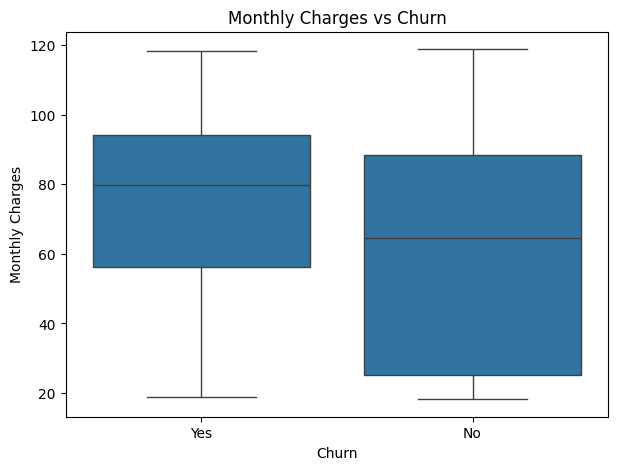

In [28]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_model,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [29]:
df_model.groupby("Churn Label")["Monthly Charges"].agg(
    ["mean", "median"]
)

,mean,median
Churn Label,,
No,61.265124,64.425
Yes,74.441332,79.650


### Monthly Charges vs Churn

Churned customers have higher average and median monthly charges
than non-churned customers. The median monthly charge is approximately
$79.65 for churned customers compared with $64.43 for non-churned
customers. This indicates that Monthly Charges is potentially an
important predictive feature.

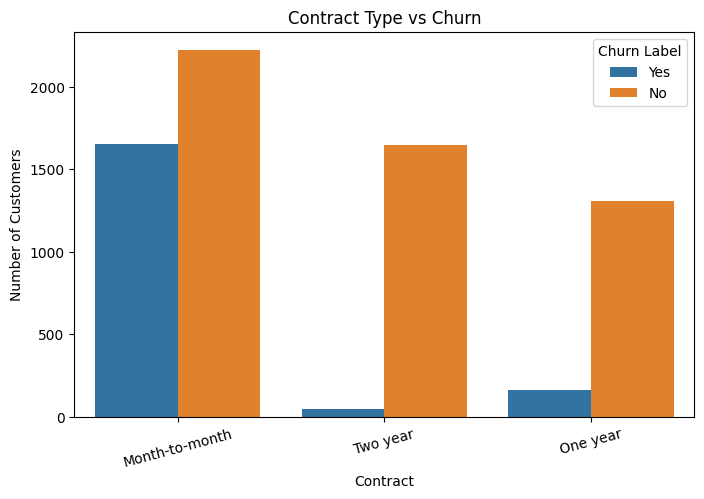

In [30]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x="Contract",
    hue="Churn Label"
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

In [31]:
contract_churn = pd.crosstab(
    df_model["Contract"],
    df_model["Churn Label"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn Label,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


Contract type shows a strong association with customer churn. Month-to-month customers have a substantially higher churn rate than customers on one-year and two-year contracts.

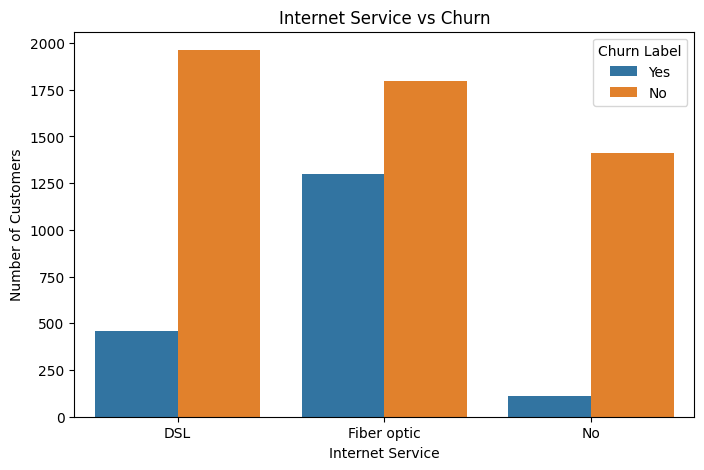

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x="Internet Service",
    hue="Churn Label"
)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [33]:
internet_churn = pd.crosstab(
    df_model["Internet Service"],
    df_model["Churn Label"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn Label,No,Yes
Internet Service,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40
